# PCA Intuition Lab: Finding the Best Projection

This notebook is a friendly, visual introduction to PCA.

The main idea:

**PCA chooses the projection direction that keeps the data as spread out as possible.**

In this notebook we will:

1. Create a 2D cloud of points.
2. Rotate a projection axis manually with a slider.
3. Measure how much variance is kept by each projection.
4. Compare our chosen projection with the PCA projection.
5. Reconstruct the data from 1D back to 2D.
6. Add a short 3D → 2D demonstration at the end.

The goal is intuition first. The linear algebra can wait politely outside for a few minutes.

## Setup

Run this cell first.

It imports the libraries and defines a shared slider style so the widgets look readable in Colab.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from sklearn.decomposition import PCA

# Reproducibility
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Shared ipywidgets slider style/layout
SLIDER_STYLE  = {'description_width': '160px'}   # enough space for labels
SLIDER_LAYOUT = widgets.Layout(width='520px')    # consistent overall width

## Part 1: Create a 2D Cloud

We will create a stretched and rotated cloud of points.

This is a good PCA example because the data has a clear main direction.

In real datasets, PCA often finds directions like this, but in many more dimensions.

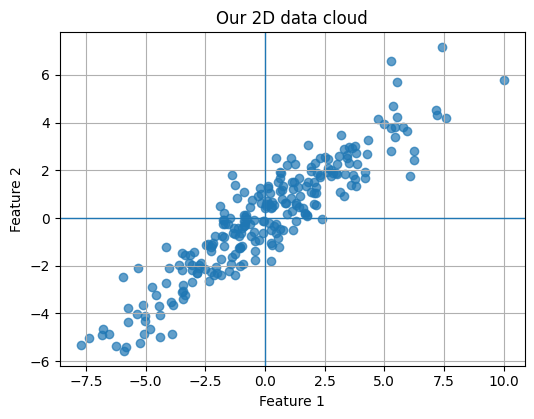

In [36]:
def make_2d_cloud(
    n_points=250,
    angle_degrees=35,
    stretch_x=4.0,
    stretch_y=0.8,
    noise=0.15,
    random_state=42
):
    """Create a 2D elliptical cloud with a chosen rotation."""
    rng = np.random.default_rng(random_state)

    # Start with standard normal points
    X = rng.normal(size=(n_points, 2))

    # Stretch the cloud before rotating it
    X[:, 0] *= stretch_x
    X[:, 1] *= stretch_y

    # Rotation matrix
    theta = np.deg2rad(angle_degrees)
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    # Rotate and add a little noise
    X = X @ R.T
    X += rng.normal(scale=noise, size=X.shape)

    # Center the data around zero
    X = X - X.mean(axis=0)

    return X


X = make_2d_cloud()

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Our 2D data cloud")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

## Part 2: What Does It Mean to Project?

A projection takes a 2D point and keeps only its position along one chosen axis.

For an axis direction $u$, the projection value of a centered point $x$ is:

$$ z = x \cdot u $$

This gives one number per point.

So we reduce:

$$ (x_1, x_2) \rightarrow z $$

The question is:

**Which axis should we choose?**

## Part 3: Interactive Projection Axis

Move the slider.

The left plot shows:

- the original 2D cloud
- the current projection axis
- the projected points on that axis

The right plot shows the 1D projected values.

When the projected values are very spread out, the projection keeps more information.

In [37]:
def unit_vector_from_angle(angle_degrees):
    """Return a 2D unit vector from an angle in degrees."""
    theta = np.deg2rad(angle_degrees)
    return np.array([np.cos(theta), np.sin(theta)])


def project_onto_axis(X, angle_degrees):
    """Project centered 2D data onto an axis defined by an angle."""
    u = unit_vector_from_angle(angle_degrees)
    z = X @ u
    X_projected = np.outer(z, u)
    variance_kept = np.var(z)
    return z, X_projected, variance_kept


def plot_projection_demo(angle_degrees):
    z, X_projected, variance_kept = project_onto_axis(X, angle_degrees)
    u = unit_vector_from_angle(angle_degrees)

    axis_length = 6
    axis_points = np.array([-axis_length * u, axis_length * u])

    fig = plt.figure(figsize=(13, 5))

    # Original cloud and projected points
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(X[:, 0], X[:, 1], alpha=0.35, label="Original points")
    ax1.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.65, label="Projected points")

    # Projection lines for a subset, to avoid visual clutter
    sample_indices = np.linspace(0, len(X) - 1, 35, dtype=int)
    for i in sample_indices:
        ax1.plot(
            [X[i, 0], X_projected[i, 0]],
            [X[i, 1], X_projected[i, 1]],
            linewidth=0.6,
            alpha=0.35
        )

    ax1.plot(axis_points[:, 0], axis_points[:, 1], linewidth=3, label="Projection axis")

    ax1.axhline(0, linewidth=1)
    ax1.axvline(0, linewidth=1)
    ax1.set_aspect("equal", adjustable="box")
    ax1.set_xlim(-7, 7)
    ax1.set_ylim(-7, 7)
    ax1.grid(True)
    ax1.set_title(f"Projection axis angle: {angle_degrees:.1f}°")
    ax1.set_xlabel("Feature 1")
    ax1.set_ylabel("Feature 2")
    ax1.legend(loc="upper left")

    # 1D projected values
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(z, np.zeros_like(z), alpha=0.65)
    ax2.axhline(0, linewidth=1)
    ax2.set_yticks([])
    ax2.set_xlim(-7, 7)
    ax2.grid(True, axis="x")
    ax2.set_title(f"1D projection\nVariance kept: {variance_kept:.3f}")
    ax2.set_xlabel("Projected value")

    plt.tight_layout()
    plt.show()

    print(f"Angle: {angle_degrees:.1f} degrees")
    print(f"Variance kept by this projection: {variance_kept:.3f}")


angle_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=180,
    step=1,
    description="Axis angle",
    style=SLIDER_STYLE,
    layout=SLIDER_LAYOUT,
    continuous_update=False
)

widgets.interact(plot_projection_demo, angle_degrees=angle_slider);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Axis angle', layout=Layout(…

## Part 4: Add a Random Angle Button

Sometimes students keep moving the slider carefully and do not get a feeling for the whole search space.

The random button helps us sample different projection angles quickly.

Each click chooses a new random angle.

In [38]:
random_angle_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=180,
    step=1,
    description="Axis angle",
    style=SLIDER_STYLE,
    layout=SLIDER_LAYOUT,
    continuous_update=False
)

random_button = widgets.Button(
    description="Random angle",
    button_style=""
)

random_output = widgets.Output()

def update_random_demo(*args):
    with random_output:
        clear_output(wait=True)
        plot_projection_demo(random_angle_slider.value)

def randomize_angle(_):
    random_angle_slider.value = float(np.random.uniform(0, 180))

random_angle_slider.observe(update_random_demo, names="value")
random_button.on_click(randomize_angle)

display(widgets.VBox([random_angle_slider, random_button, random_output]))
update_random_demo()

## Part 5: Variance as a Function of the Angle

Now we calculate the projected variance for many possible angles.

This lets us see PCA as an optimization problem:

$$ \text{best axis} = \arg\max_{\theta} \operatorname{Var}(X u_\theta) $$

In friendly words:

**Try many directions and choose the one where the projected data is most spread out.**

Best angle by brute-force search: 36.5 degrees
Best projected variance: 15.090


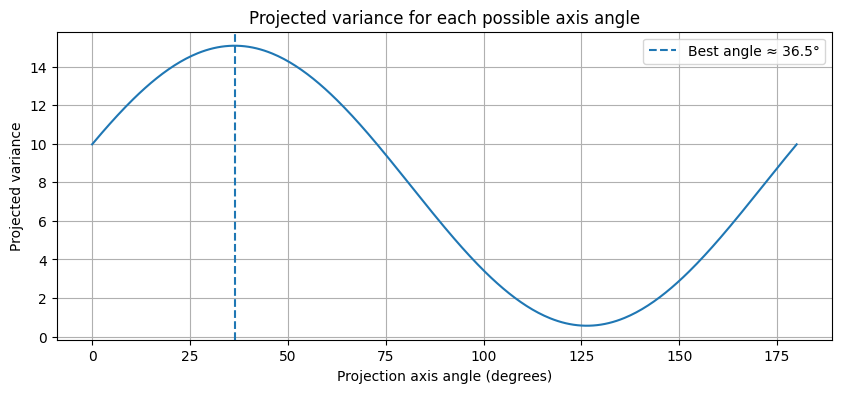

In [39]:
angles = np.linspace(0, 180, 361)
variances = []

for angle in angles:
    _, _, variance_kept = project_onto_axis(X, angle)
    variances.append(variance_kept)

variances = np.array(variances)
best_angle_by_search = angles[np.argmax(variances)]
best_variance_by_search = variances.max()

print(f"Best angle by brute-force search: {best_angle_by_search:.1f} degrees")
print(f"Best projected variance: {best_variance_by_search:.3f}")

plt.figure(figsize=(10, 4))
plt.plot(angles, variances)
plt.axvline(best_angle_by_search, linestyle="--", label=f"Best angle ≈ {best_angle_by_search:.1f}°")
plt.title("Projected variance for each possible axis angle")
plt.xlabel("Projection axis angle (degrees)")
plt.ylabel("Projected variance")
plt.grid(True)
plt.legend()
plt.show()

## Part 6: Interactive Search View

This time, the plot includes:

- the current projection
- the full angle-versus-variance curve
- a vertical line showing the current angle

This is usually the clearest “PCA is looking for the best direction” visualization.

In [ ]:
def plot_projection_with_variance_curve(angle_degrees):
    z, X_projected, variance_kept = project_onto_axis(X, angle_degrees)
    u = unit_vector_from_angle(angle_degrees)

    axis_length = 6
    axis_points = np.array([-axis_length * u, axis_length * u])

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(X[:, 0], X[:, 1], alpha=0.35)
    ax1.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.65)

    sample_indices = np.linspace(0, len(X) - 1, 35, dtype=int)
    for i in sample_indices:
        ax1.plot(
            [X[i, 0], X_projected[i, 0]],
            [X[i, 1], X_projected[i, 1]],
            linewidth=0.6,
            alpha=0.35
        )

    ax1.plot(axis_points[:, 0], axis_points[:, 1], linewidth=3)
    ax1.axhline(0, linewidth=1)
    ax1.axvline(0, linewidth=1)
    ax1.set_aspect("equal", adjustable="box")
    ax1.set_xlim(-7, 7)
    ax1.set_ylim(-7, 7)
    ax1.grid(True)
    ax1.set_title(f"Current projection\nVariance kept: {variance_kept:.3f}")
    ax1.set_xlabel("Feature 1")
    ax1.set_ylabel("Feature 2")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(angles, variances)
    ax2.axvline(angle_degrees, linestyle="--", label=f"Current angle: {angle_degrees:.1f}°")
    ax2.axvline(best_angle_by_search, linestyle=":", label=f"Best angle: {best_angle_by_search:.1f}°")
    ax2.scatter([angle_degrees], [variance_kept], s=80)
    ax2.set_title("How good is each angle?")
    ax2.set_xlabel("Projection axis angle (degrees)")
    ax2.set_ylabel("Projected variance")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    percent_of_best = 100 * variance_kept / best_variance_by_search
    print(f"Current variance: {variance_kept:.3f}")
    print(f"Best possible variance: {best_variance_by_search:.3f}")
    print(f"You captured {percent_of_best:.1f}% of the best possible variance.")


search_angle_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=180,
    step=1,
    description="Axis angle",
    style=SLIDER_STYLE,
    layout=SLIDER_LAYOUT,
    continuous_update=False
)

random_search_button = widgets.Button(description="Random angle")
search_output = widgets.Output()

def update_search_demo(*args):
    with search_output:
        clear_output(wait=True)
        plot_projection_with_variance_curve(search_angle_slider.value)

def randomize_search_angle(_):
    search_angle_slider.value = float(np.random.uniform(0, 180))

search_angle_slider.observe(update_search_demo, names="value")
random_search_button.on_click(randomize_search_angle)

display(widgets.VBox([search_angle_slider, random_search_button, search_output]))
update_search_demo()

## Part 7: Compare with `sklearn` PCA

Now we let `sklearn` run PCA.

PCA will find the first principal component, also called **PC1**.

PC1 is the direction where the projection has maximum variance.

The direction itself is a vector:

$$ u = (u_1, u_2) $$

The projected value of each point is still:

$$ z = x \cdot u $$

In [41]:
pca_1d = PCA(n_components=1)
z_pca = pca_1d.fit_transform(X)

pc1 = pca_1d.components_[0]
pca_angle = np.rad2deg(np.arctan2(pc1[1], pc1[0]))

# Convert to the 0..180 range because an axis has no arrow direction.
# Angle 35° and 215° represent the same projection axis.
pca_angle = pca_angle % 180

pca_variance = np.var(z_pca[:, 0])

print("PCA direction vector:")
print(pc1)
print()
print(f"PCA angle: {pca_angle:.1f} degrees")
print(f"PCA projected variance: {pca_variance:.3f}")
print(f"Best brute-force angle: {best_angle_by_search:.1f} degrees")
print(f"Best brute-force projected variance: {best_variance_by_search:.3f}")

PCA direction vector:
[0.80484638 0.5934832 ]

PCA angle: 36.4 degrees
PCA projected variance: 15.090
Best brute-force angle: 36.5 degrees
Best brute-force projected variance: 15.090


The brute-force search and `sklearn` PCA may differ by a tiny amount because our brute-force search checks only a grid of angles.

That is fine.

The important point is that both methods point to the same main direction of the cloud.

In [42]:
def plot_student_vs_pca(student_angle):
    student_z, _, student_variance = project_onto_axis(X, student_angle)
    pca_z, _, pca_variance_manual = project_onto_axis(X, pca_angle)

    student_u = unit_vector_from_angle(student_angle)
    pca_u = unit_vector_from_angle(pca_angle)

    axis_length = 6

    plt.figure(figsize=(7, 7))
    plt.scatter(X[:, 0], X[:, 1], alpha=0.45)

    student_axis = np.array([-axis_length * student_u, axis_length * student_u])
    pca_axis = np.array([-axis_length * pca_u, axis_length * pca_u])

    plt.plot(student_axis[:, 0], student_axis[:, 1], linewidth=3, label=f"Your axis: {student_angle:.1f}°")
    plt.plot(pca_axis[:, 0], pca_axis[:, 1], linewidth=3, linestyle="--", label=f"PCA axis: {pca_angle:.1f}°")

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlim(-7, 7)
    plt.ylim(-7, 7)
    plt.grid(True)
    plt.legend()
    plt.title("Your chosen axis versus the PCA axis")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

    print(f"Your projected variance: {student_variance:.3f}")
    print(f"PCA projected variance: {pca_variance_manual:.3f}")
    print(f"You captured {100 * student_variance / pca_variance_manual:.1f}% of the PCA variance.")


guess_slider = widgets.FloatSlider(
    value=20,
    min=0,
    max=180,
    step=1,
    description="Your guess",
    style=SLIDER_STYLE,
    layout=SLIDER_LAYOUT,
    continuous_update=False
)

reveal_button = widgets.Button(description="Reveal PCA")
guess_output = widgets.Output()

def reveal_pca(_):
    with guess_output:
        clear_output(wait=True)
        plot_student_vs_pca(guess_slider.value)

display(widgets.VBox([
    widgets.HTML("<b>Challenge:</b> choose the PCA angle manually, then press Reveal PCA."),
    guess_slider,
    reveal_button,
    guess_output
]))

reveal_button.on_click(reveal_pca)

## Part 8: PCA and Reconstruction Error

There is another way to understand PCA.

When we reduce 2D data to 1D, we lose some information.

But after projection, we can still reconstruct an approximation of the original 2D points.

A good projection gives a better reconstruction.

A bad projection gives a worse reconstruction.

For a point $x$, projection to one dimension gives:

$$ z = x \cdot u $$

Reconstruction back to two dimensions gives:

$$ \hat{x} = z u $$

The reconstruction error is:

$$ \|x - \hat{x}\|^2 $$

PCA chooses the 1D direction that minimizes the average reconstruction error.

In [ ]:
def reconstruction_error_for_angle(X, angle_degrees):
    z, X_reconstructed, _ = project_onto_axis(X, angle_degrees)
    squared_errors = np.sum((X - X_reconstructed) ** 2, axis=1)
    return squared_errors.mean(), X_reconstructed


def plot_reconstruction(angle_degrees):
    error, X_reconstructed = reconstruction_error_for_angle(X, angle_degrees)
    _, _, variance_kept = project_onto_axis(X, angle_degrees)

    plt.figure(figsize=(7, 7))
    plt.scatter(X[:, 0], X[:, 1], alpha=0.35, label="Original points")
    plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.7, label="Reconstructed points")

    sample_indices = np.linspace(0, len(X) - 1, 35, dtype=int)
    for i in sample_indices:
        plt.plot(
            [X[i, 0], X_reconstructed[i, 0]],
            [X[i, 1], X_reconstructed[i, 1]],
            linewidth=0.6,
            alpha=0.35
        )

    u = unit_vector_from_angle(angle_degrees)
    axis_length = 6
    axis_points = np.array([-axis_length * u, axis_length * u])
    plt.plot(axis_points[:, 0], axis_points[:, 1], linewidth=3, label="Projection axis")

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlim(-7, 7)
    plt.ylim(-7, 7)
    plt.grid(True)
    plt.legend()
    plt.title(f"Reconstruction from 1D projection\nVariance kept: {variance_kept:.3f}, Mean squared error: {error:.3f}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


reconstruction_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=180,
    step=1,
    description="Axis angle",
    style=SLIDER_STYLE,
    layout=SLIDER_LAYOUT,
    continuous_update=False
)

widgets.interact(plot_reconstruction, angle_degrees=reconstruction_slider);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Axis angle', layout=Layout(…

## Part 9: New Cloud Button

If the cloud always looks the same, students may accidentally memorize one answer.

This section generates a new cloud with a random rotation and random stretching.

Try pressing **New cloud** several times.

The PCA direction changes, but the principle stays the same:

**PCA finds the direction where the projected data is most spread out.**

In [44]:
cloud_output = widgets.Output()
new_cloud_button = widgets.Button(description="New cloud")

cloud_angle_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=180,
    step=1,
    description="Axis angle",
    style=SLIDER_STYLE,
    layout=SLIDER_LAYOUT,
    continuous_update=False
)

current_cloud = {"X": X}

def make_random_cloud():
    random_angle = np.random.uniform(0, 180)
    stretch_x = np.random.uniform(2.5, 5.5)
    stretch_y = np.random.uniform(0.3, 1.5)
    random_state = np.random.randint(0, 1_000_000)

    return make_2d_cloud(
        angle_degrees=random_angle,
        stretch_x=stretch_x,
        stretch_y=stretch_y,
        random_state=random_state
    )

def plot_current_cloud_demo():
    X_local = current_cloud["X"]

    def local_project(angle_degrees):
        u = unit_vector_from_angle(angle_degrees)
        z = X_local @ u
        X_projected = np.outer(z, u)
        variance_kept = np.var(z)
        return z, X_projected, variance_kept

    angle_degrees = cloud_angle_slider.value
    z, X_projected, variance_kept = local_project(angle_degrees)

    local_angles = np.linspace(0, 180, 361)
    local_variances = []
    for angle in local_angles:
        _, _, local_variance = local_project(angle)
        local_variances.append(local_variance)

    local_variances = np.array(local_variances)
    local_best_angle = local_angles[np.argmax(local_variances)]

    u = unit_vector_from_angle(angle_degrees)
    axis_length = 6
    axis_points = np.array([-axis_length * u, axis_length * u])

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(X_local[:, 0], X_local[:, 1], alpha=0.4)
    ax1.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.65)
    ax1.plot(axis_points[:, 0], axis_points[:, 1], linewidth=3)
    ax1.axhline(0, linewidth=1)
    ax1.axvline(0, linewidth=1)
    ax1.set_aspect("equal", adjustable="box")
    ax1.set_xlim(-7, 7)
    ax1.set_ylim(-7, 7)
    ax1.grid(True)
    ax1.set_title(f"Current projection\nVariance kept: {variance_kept:.3f}")
    ax1.set_xlabel("Feature 1")
    ax1.set_ylabel("Feature 2")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(local_angles, local_variances)
    ax2.axvline(angle_degrees, linestyle="--", label=f"Current: {angle_degrees:.1f}°")
    ax2.axvline(local_best_angle, linestyle=":", label=f"PCA-like best: {local_best_angle:.1f}°")
    ax2.set_title("Projected variance by angle")
    ax2.set_xlabel("Projection axis angle (degrees)")
    ax2.set_ylabel("Projected variance")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def refresh_cloud_output(*args):
    with cloud_output:
        clear_output(wait=True)
        plot_current_cloud_demo()

def generate_new_cloud(_):
    current_cloud["X"] = make_random_cloud()
    refresh_cloud_output()

cloud_angle_slider.observe(refresh_cloud_output, names="value")
new_cloud_button.on_click(generate_new_cloud)

display(widgets.VBox([cloud_angle_slider, new_cloud_button, cloud_output]))
refresh_cloud_output()

## Mini Exercise 1: Calculate Projected Variance

Complete the function below.

The input is:

- `X_input`: a centered dataset with shape `(n_samples, 2)`
- `angle_degrees`: the projection angle

The output should be the variance of the projected values.

Reminder:

$$ z = X u $$

where:

$$ u = (\cos\theta, \sin\theta) $$

In [45]:
# YOUR CODE HERE

def projected_variance_student(X_input, angle_degrees):
    # 1. Convert angle from degrees to radians
    # 2. Create the unit vector u
    # 3. Project X_input onto u
    # 4. Return the variance of the projected values

    pass


# Try it:
# projected_variance_student(X, 35)

In [46]:
# SOLUTION

def projected_variance_solution(X_input, angle_degrees):
    theta = np.deg2rad(angle_degrees)
    u = np.array([np.cos(theta), np.sin(theta)])
    z = X_input @ u
    return np.var(z)


projected_variance_solution(X, 35)

np.float64(15.080828392403328)

## Mini Exercise 2: Find the Best Angle by Search

Complete the function below.

The function should:

1. Try many angles between 0 and 180.
2. Calculate the projected variance for each angle.
3. Return the angle with the highest projected variance.

This is not the fastest PCA algorithm, but it is very intuitive.

In [47]:
# YOUR CODE HERE

def find_best_angle_student(X_input):
    candidate_angles = np.linspace(0, 180, 361)

    # Calculate the variance for every candidate angle
    # Find the angle with the largest variance
    # Return that angle

    pass


# Try it:
# find_best_angle_student(X)

In [48]:
# SOLUTION

def find_best_angle_solution(X_input):
    candidate_angles = np.linspace(0, 180, 361)
    candidate_variances = []

    for angle in candidate_angles:
        variance = projected_variance_solution(X_input, angle)
        candidate_variances.append(variance)

    candidate_variances = np.array(candidate_variances)
    best_index = np.argmax(candidate_variances)

    return candidate_angles[best_index]


find_best_angle_solution(X)

np.float64(36.5)

# Addendum: 3D Data Projected to 2D

The main narrative of this notebook was 2D → 1D.

Now we briefly look at 3D → 2D.

The idea is the same, but instead of choosing the best line, PCA chooses the best plane.

In 3D:

- PC1 is the strongest direction.
- PC2 is the second strongest direction, perpendicular to PC1.
- Together, PC1 and PC2 define a 2D plane.
- PC3 is the direction with the least remaining variance.

If the data is shaped like a thin tilted pancake, then PC1 and PC2 capture most of the structure.

## Create a Tilted 3D Pancake

We create 3D data where two directions have high variance and one direction has low variance.

That means the cloud is almost flat, but tilted in 3D space.

In [49]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

def rotation_matrix_3d(alpha, beta, gamma):
    """Create a 3D rotation matrix from three angles in radians."""
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(alpha)],
        [0, np.sin(alpha),  np.cos(alpha)]
    ])

    Ry = np.array([
        [ np.cos(beta), 0, np.sin(beta)],
        [0, 1, 0],
        [-np.sin(beta), 0, np.cos(beta)]
    ])

    Rz = np.array([
        [np.cos(gamma), -np.sin(gamma), 0],
        [np.sin(gamma),  np.cos(gamma), 0],
        [0, 0, 1]
    ])

    return Rz @ Ry @ Rx


def make_3d_pancake(n_points=450, random_state=7):
    rng = np.random.default_rng(random_state)

    X3 = rng.normal(size=(n_points, 3))

    # Strong spread in two dimensions, weak spread in the third
    X3[:, 0] *= 4.0
    X3[:, 1] *= 2.0
    X3[:, 2] *= 0.35

    # Tilt the pancake in 3D
    R = rotation_matrix_3d(
        alpha=np.deg2rad(25),
        beta=np.deg2rad(40),
        gamma=np.deg2rad(20)
    )

    X3 = X3 @ R.T

    # Center the data around zero
    X3 = X3 - X3.mean(axis=0)

    return X3


X3 = make_3d_pancake()

# Fit PCA with 2 components.
# These two components define the best 2D plane through the 3D cloud.
pca_2d = PCA(n_components=2)
pca_2d.fit(X3)

mean_point = X3.mean(axis=0)
pc1 = pca_2d.components_[0]
pc2 = pca_2d.components_[1]

# Create a rectangular grid in the PCA plane
plane_size = 7

u = np.linspace(-plane_size, plane_size, 15)
v = np.linspace(-plane_size, plane_size, 15)

U, V = np.meshgrid(u, v)

plane_x = mean_point[0] + U * pc1[0] + V * pc2[0]
plane_y = mean_point[1] + U * pc1[1] + V * pc2[1]
plane_z = mean_point[2] + U * pc1[2] + V * pc2[2]

fig = go.Figure()

# Original 3D points
fig.add_trace(
    go.Scatter3d(
        x=X3[:, 0],
        y=X3[:, 1],
        z=X3[:, 2],
        mode="markers",
        name="Original 3D points",
        marker=dict(
            size=3,
            opacity=0.65
        )
    )
)

# PCA plane
fig.add_trace(
    go.Surface(
        x=plane_x,
        y=plane_y,
        z=plane_z,
        opacity=0.35,
        showscale=False,
        name="PCA plane"
    )
)

fig.update_layout(
    title="Original 3D cloud: a tilted pancake, with the PCA 2D plane",
    scene=dict(
        xaxis_title="Feature 1",
        yaxis_title="Feature 2",
        zaxis_title="Feature 3",
        aspectmode="data"
    ),
    width=850,
    height=700
)

fig.show()

print("Explained variance ratio:")
print(pca_2d.explained_variance_ratio_)
print()
print(f"Total variance kept by PC1 + PC2: {pca_2d.explained_variance_ratio_.sum() * 100:.1f}%")

Explained variance ratio:
[0.80765189 0.18633815]

Total variance kept by PC1 + PC2: 99.4%


## PCA from 3D to 2D

Now we ask PCA to reduce the data from 3 features to 2 features.

This means:

$$ (x_1, x_2, x_3) \rightarrow (z_1, z_2) $$

The two new features are the coordinates of each point in the PCA plane.

The explained variance ratio tells us how much of the total variance is kept by each principal component.

Explained variance ratio:
[0.80765189 0.18633815]

Total variance kept by PC1 + PC2: 99.4%


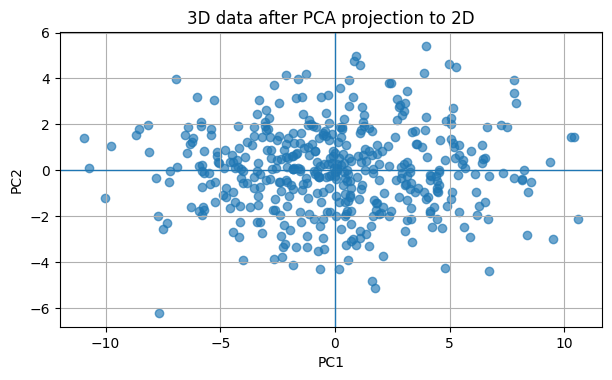

In [50]:
pca_2d = PCA(n_components=2)
X3_projected_2d = pca_2d.fit_transform(X3)

print("Explained variance ratio:")
print(pca_2d.explained_variance_ratio_)
print()
print(f"Total variance kept by PC1 + PC2: {pca_2d.explained_variance_ratio_.sum() * 100:.1f}%")

plt.figure(figsize=(7, 6))
plt.scatter(X3_projected_2d[:, 0], X3_projected_2d[:, 1], alpha=0.65)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("3D data after PCA projection to 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Reconstruct 3D Points from the 2D PCA Projection

We can project the 3D points to 2D and reconstruct them back to 3D.

If the original data really was close to a plane, the reconstruction should be close to the original.

This is the same story as before:

**PCA keeps the strongest directions and drops the weaker directions.**

In [51]:
import plotly.graph_objects as go

X3_reconstructed = pca_2d.inverse_transform(X3_projected_2d)

reconstruction_mse_3d = np.mean(np.sum((X3 - X3_reconstructed) ** 2, axis=1))
print(f"Mean squared reconstruction error after 3D → 2D PCA: {reconstruction_mse_3d:.3f}")

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=X3[:, 0],
    y=X3[:, 1],
    z=X3[:, 2],
    mode="markers",
    name="Original 3D points",
    marker=dict(
        size=3,
        opacity=0.25
    )
))

fig.add_trace(go.Scatter3d(
    x=X3_reconstructed[:, 0],
    y=X3_reconstructed[:, 1],
    z=X3_reconstructed[:, 2],
    mode="markers",
    name="Reconstructed from 2D PCA",
    marker=dict(
        size=3,
        opacity=0.75
    )
))

fig.update_layout(
    title="Original 3D points and their reconstruction from 2D PCA",
    scene=dict(
        xaxis_title="Feature 1",
        yaxis_title="Feature 2",
        zaxis_title="Feature 3"
    ),
    width=800,
    height=650
)

fig.show()

Mean squared reconstruction error after 3D → 2D PCA: 0.114


## Final Summary

PCA can sound complicated, but the core idea is friendly:

1. Choose a lower-dimensional space.
2. Project the data onto it.
3. Keep as much variance as possible.
4. This also gives a low reconstruction error.

For 2D → 1D:

**PCA chooses the best line.**

For 3D → 2D:

**PCA chooses the best plane.**

For larger datasets:

**PCA chooses the best lower-dimensional space.**

The math becomes more advanced, but the intuition stays the same.